<a href="https://colab.research.google.com/github/Pedro-0101/Conversor-csv/blob/master/trabalho_analise_de_dados_07_05_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Relatorio de Analise: Fatores de Rendimento Estudantil

### 1. Contexto e Objetivos
Este estudo visa identificar os determinantes do desempenho acadêmico, focando em como hábitos individuais, suporte familiar e fatores socioeconômicos influenciam a nota final (`Exam_Score`).

**Metas Principais:**
1. Determinar o peso de fatores no desempenho dos alunos.
2. Identificar padrões de eficiência no aprendizado.
3. Propor recomendações baseadas em dados.

### 2. Metodologia de Preparação
- **Codificação Ordinal/Binária:** Variáveis categóricas foram convertidas em escalas numéricas para permitir análises estatísticas.
- **Engenharia de Atributos:** Criação de métricas como `Study_Efficiency` e `Score_Improvement`.
- **Tratamento de Outliers:** Remoção de valores extremos para evitar distorções em visualizações.

# Analise de dados - Desempenho estudantil
### Pedro Paulino Pinto

### Dicionário de dados (Métricas Calculadas)
- `Study_Efficiency`: Eficiência de estudo (Exam_Score / Hours_Studied)
- `Score_Improvement`: Evolução da nota (Exam_Score - Previous_Scores)
- `Improvement_Per_Hour`: Taxa de melhoria por hora estudada

### Dicionário de Dados (Base)
- `Hours_Studied`: Horas de estudo
- `Attendance`: Comparecimento
- `Parental_Involvement`: Envolvimento parental
- `Access_to_Resources`: Acesso a recursos
- `Extracurricular_Activities`: Atividades extracurriculares
- `Sleep_Hours`: Horas de sono
- `Previous_Scores`: Pontuações anteriores
- `Motivation_Level`: Nível de motivação
- `Internet_Access`: Acesso à internet
- `Tutoring_Sessions`: Sessões de tutoria
- `Family_Income`: Renda familiar
- `Teacher_Quality`: Qualidade do professor
- `School_Type`: Tipo de escola
- `Peer_Influence`: Influência dos colegas
- `Physical_Activity`: Atividade física
- `Learning_Disabilities`: Dificuldades de aprendizagem
- `Parental_Education_Level`: Nível de escolaridade dos pais
- `Distance_from_Home`: Distância de casa
- `Gender`: Gênero
- `Exam_Score`: Pontuação no exame

### Importação de Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Configuração do Ambiente e Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/trabalho_ad_rendimento_estudantil"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Carregamento e Limpeza Inicial dos Dados

In [ ]:
df = pd.read_csv(path + '/03_desempenho_estudantil.csv')

initial_rows = df.shape[0]
df = df[(df['Exam_Score'] >= 0) & (df['Exam_Score'] <= 100)]
removed_rows = initial_rows - df.shape[0]

print(f"Número inicial de registros: {initial_rows}")
print(f"Número de registros removidos (Notas < 0 ou > 100): {removed_rows}")
print(f"Número final de registros: {df.shape[0]}")


df.head(10)

Número inicial de registros: 6607
Número de registros removidos (Notas < 0 ou > 100): 1
Número final de registros: 6606


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


In [ ]:
from IPython.display import Markdown, display

total_registros = df.shape[0]
total_atributos = df.shape[1]

md_content = f"""
### Detalhes Dinâmicos do Dataset

**Volume de Dados:**
- **Total de Registros:** {total_registros:,}
- **Total de Atributos:** {total_atributos}

### Descrição das Variáveis e Tipagem
"""
display(Markdown(md_content))
display(df.dtypes.to_frame('Tipo de Dado'))


### Detalhes Dinâmicos do Dataset

**Volume de Dados:**
- **Total de Registros:** 6,606
- **Total de Atributos:** 20

### Descrição das Variáveis e Tipagem


,Tipo de Dado
Hours_Studied,int64
Attendance,int64
Parental_Involvement,object
Access_to_Resources,object
Extracurricular_Activities,object
Sleep_Hours,int64
Previous_Scores,int64
Motivation_Level,object
Internet_Access,object
Tutoring_Sessions,int64


### Visualização da Distribuição das Notas

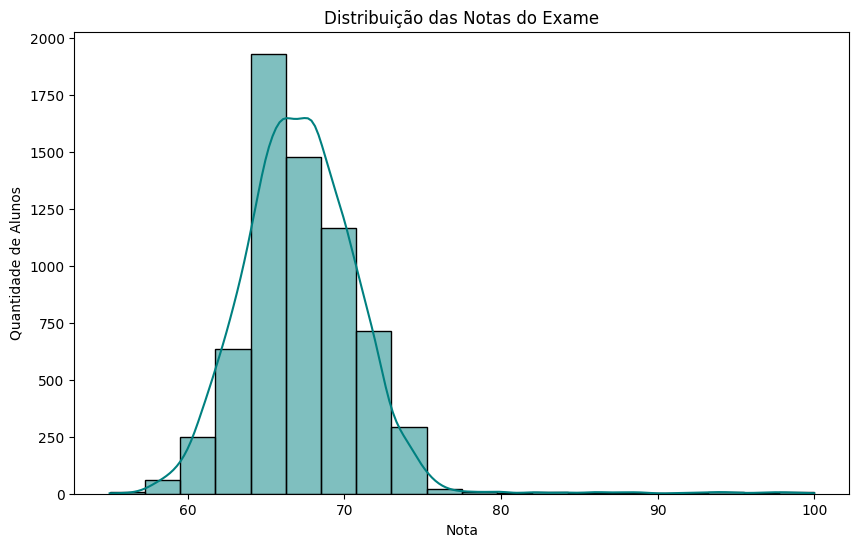

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Exam_Score'], bins=20, kde=True, color='teal')
plt.title('Distribuição das Notas do Exame')
plt.xlabel('Nota')
plt.ylabel('Quantidade de Alunos')
plt.show()

### Codificação de Variáveis e Matriz de Correlação

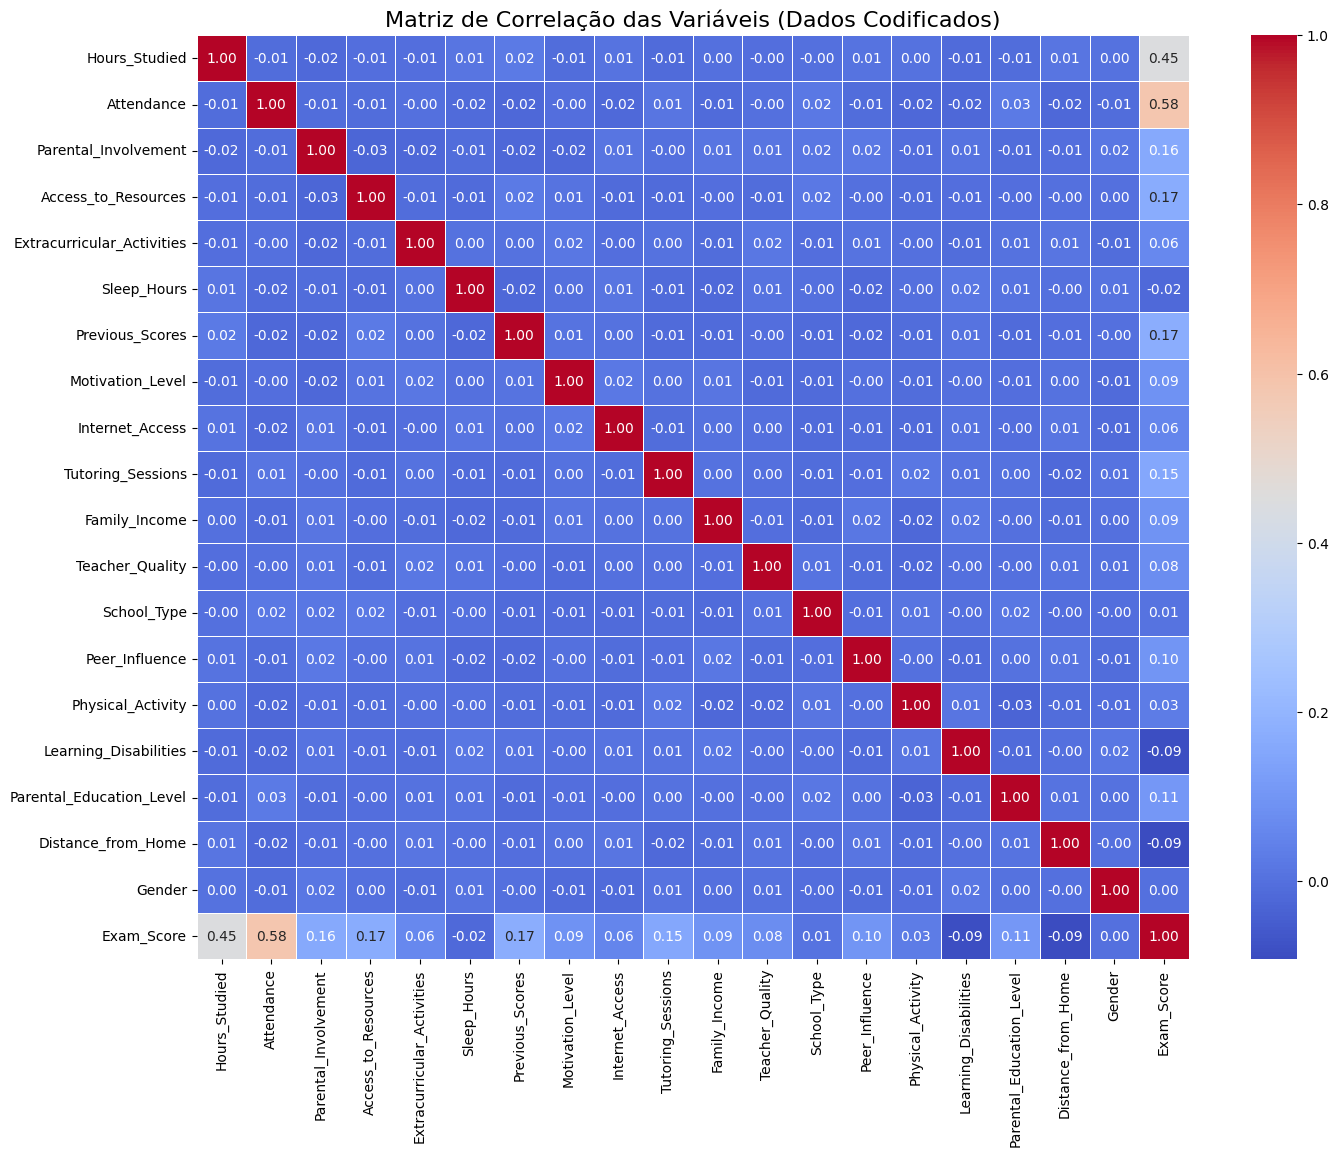

In [ ]:
mapping_low_medium_high = {'Low': 0, 'Medium': 1, 'High': 2}
mapping_negative_neutral_positive = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
mapping_highschool_college_postgraduate = {'High School': 0, 'College': 1, 'Postgraduate': 2}
mapping_near_moderate_far = {'Near': 0, 'Moderate': 1, 'Far': 2}

mapping_no_yes = {'No': 0, 'Yes': 1}
mapping_public_private = {'Public': 0, 'Private': 1}
mapping_male_female = {'Male': 0, 'Female': 1}

df_encoded = df.copy()

df_encoded['Parental_Involvement'] = df_encoded['Parental_Involvement'].map(mapping_low_medium_high)
df_encoded['Access_to_Resources'] = df_encoded['Access_to_Resources'].map(mapping_low_medium_high)
df_encoded['Motivation_Level'] = df_encoded['Motivation_Level'].map(mapping_low_medium_high)
df_encoded['Family_Income'] = df_encoded['Family_Income'].map(mapping_low_medium_high)
df_encoded['Teacher_Quality'] = df_encoded['Teacher_Quality'].map(mapping_low_medium_high)

df_encoded['Extracurricular_Activities'] = df_encoded['Extracurricular_Activities'].map(mapping_no_yes)
df_encoded['Internet_Access'] = df_encoded['Internet_Access'].map(mapping_no_yes)
df_encoded['Learning_Disabilities'] = df_encoded['Learning_Disabilities'].map(mapping_no_yes)

df_encoded['School_Type'] = df_encoded['School_Type'].map(mapping_public_private)

df_encoded['Peer_Influence'] = df_encoded['Peer_Influence'].map(mapping_negative_neutral_positive)

df_encoded['Parental_Education_Level'] = df_encoded['Parental_Education_Level'].map(mapping_highschool_college_postgraduate)

df_encoded['Distance_from_Home'] = df_encoded['Distance_from_Home'].map(mapping_near_moderate_far)

df_encoded['Gender'] = df_encoded['Gender'].map(mapping_male_female)

plt.figure(figsize=(16, 12))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação das Variáveis (Dados Codificados)', fontsize=16)
plt.show()

### Análise de Importância de Atributos (Random Forest)

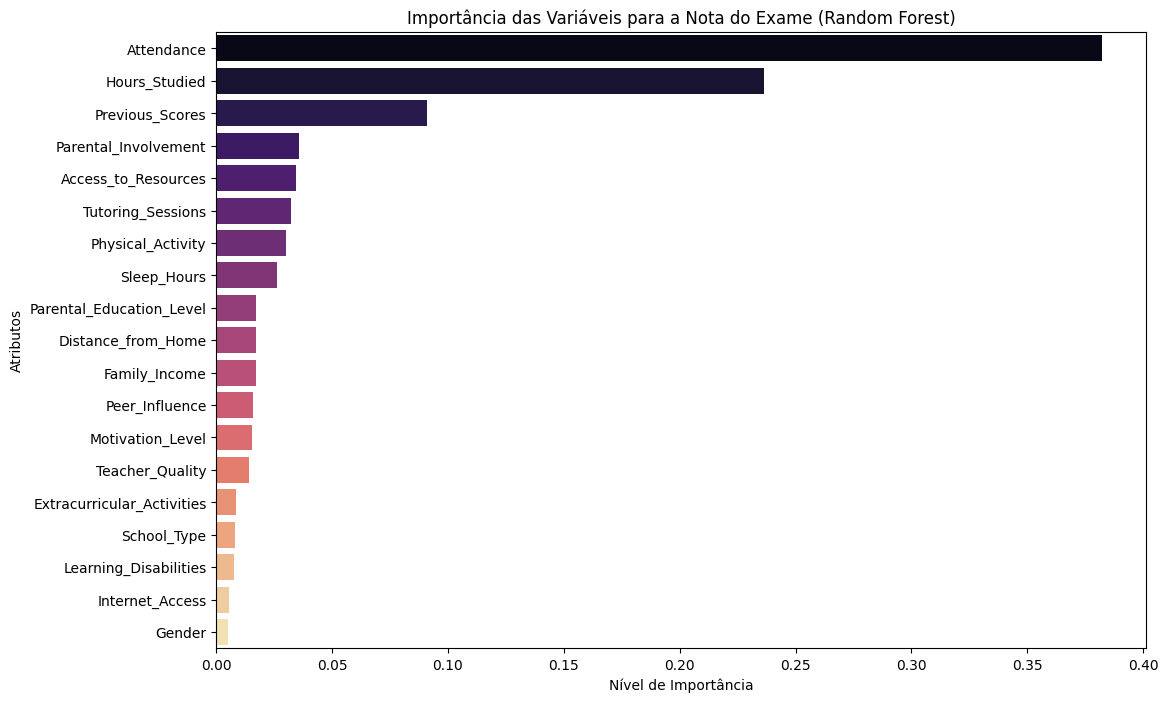

,Feature,Importance
1,Attendance,0.382254
0,Hours_Studied,0.236270
6,Previous_Scores,0.090980
2,Parental_Involvement,0.035915
3,Access_to_Resources,0.034215
9,Tutoring_Sessions,0.032361
14,Physical_Activity,0.030015
5,Sleep_Hours,0.026332
16,Parental_Education_Level,0.017201
17,Distance_from_Home,0.017091


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Exam_Score'])
y = df_encoded['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importances, palette='magma', hue='Feature', legend=False)
plt.title('Importância das Variáveis para a Nota do Exame (Random Forest)')
plt.xlabel('Nível de Importância')
plt.ylabel('Atributos')
plt.show()

display(importances)

### Análise de Sono e Desempenho

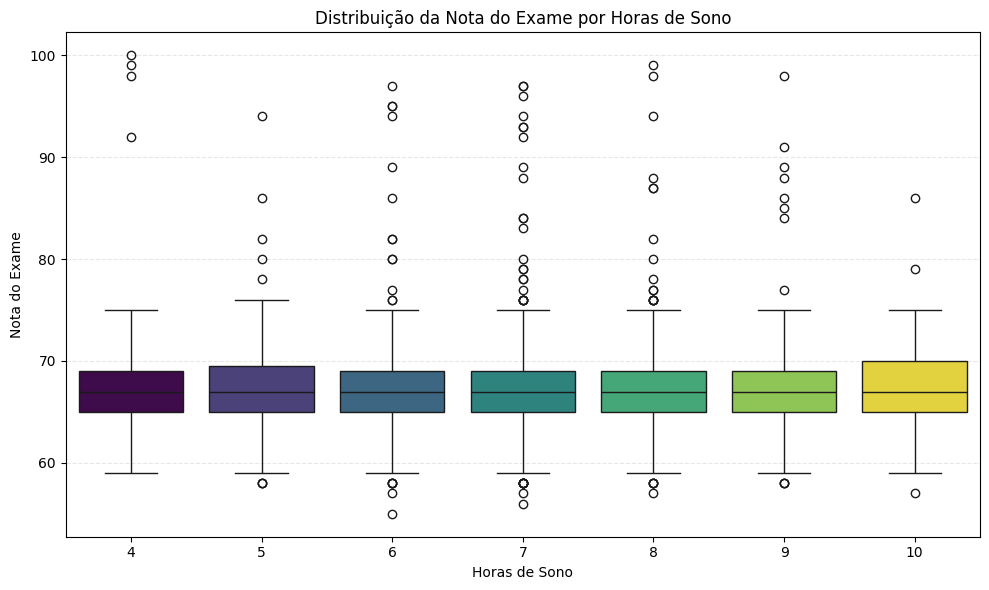

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='Sleep_Hours',
    y='Exam_Score',
    data=df,
    palette='viridis',
    hue='Sleep_Hours',
    legend=False
)
plt.title('Distribuição da Nota do Exame por Horas de Sono')
plt.xlabel('Horas de Sono')
plt.ylabel('Nota do Exame')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Relação entre Horas de Estudo e Nota

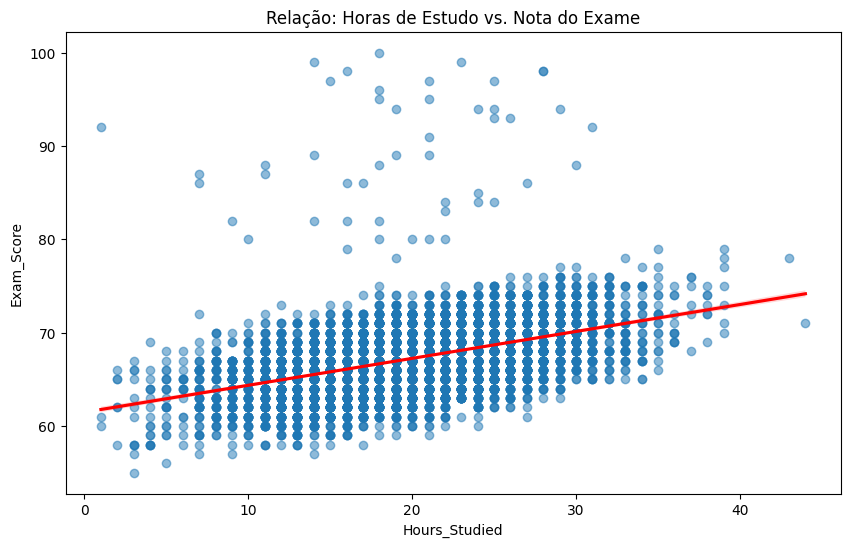

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Hours_Studied', y='Exam_Score', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relação: Horas de Estudo vs. Nota do Exame')
plt.show()

### Impacto das Sessões de Tutoria

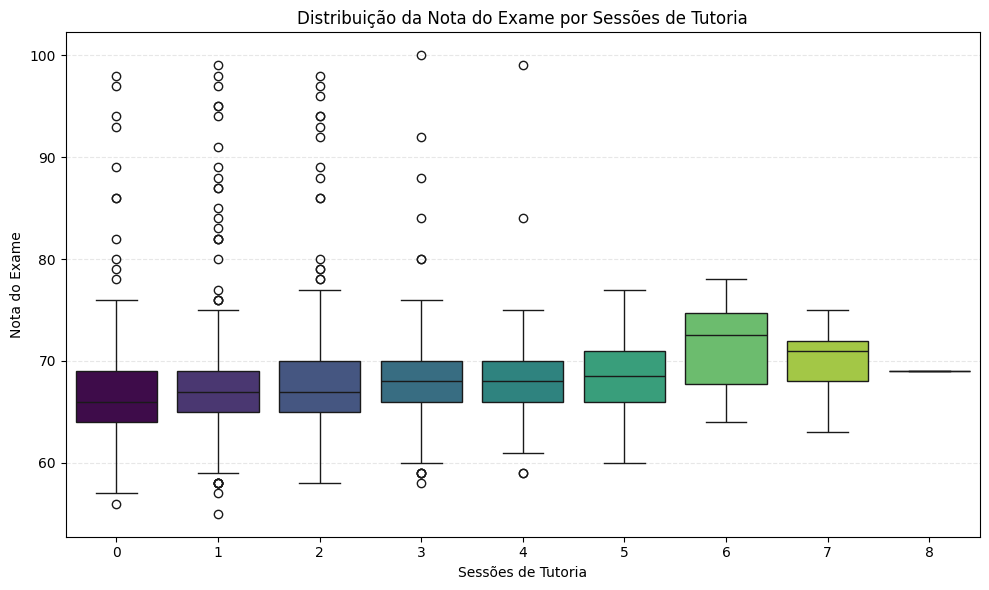

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Tutoring_Sessions', y='Exam_Score', data=df, palette='viridis', hue='Tutoring_Sessions', legend=False)
plt.title('Distribuição da Nota do Exame por Sessões de Tutoria')
plt.xlabel('Sessões de Tutoria')
plt.ylabel('Nota do Exame')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Visão Geral: Fatores vs. Nota do Exame

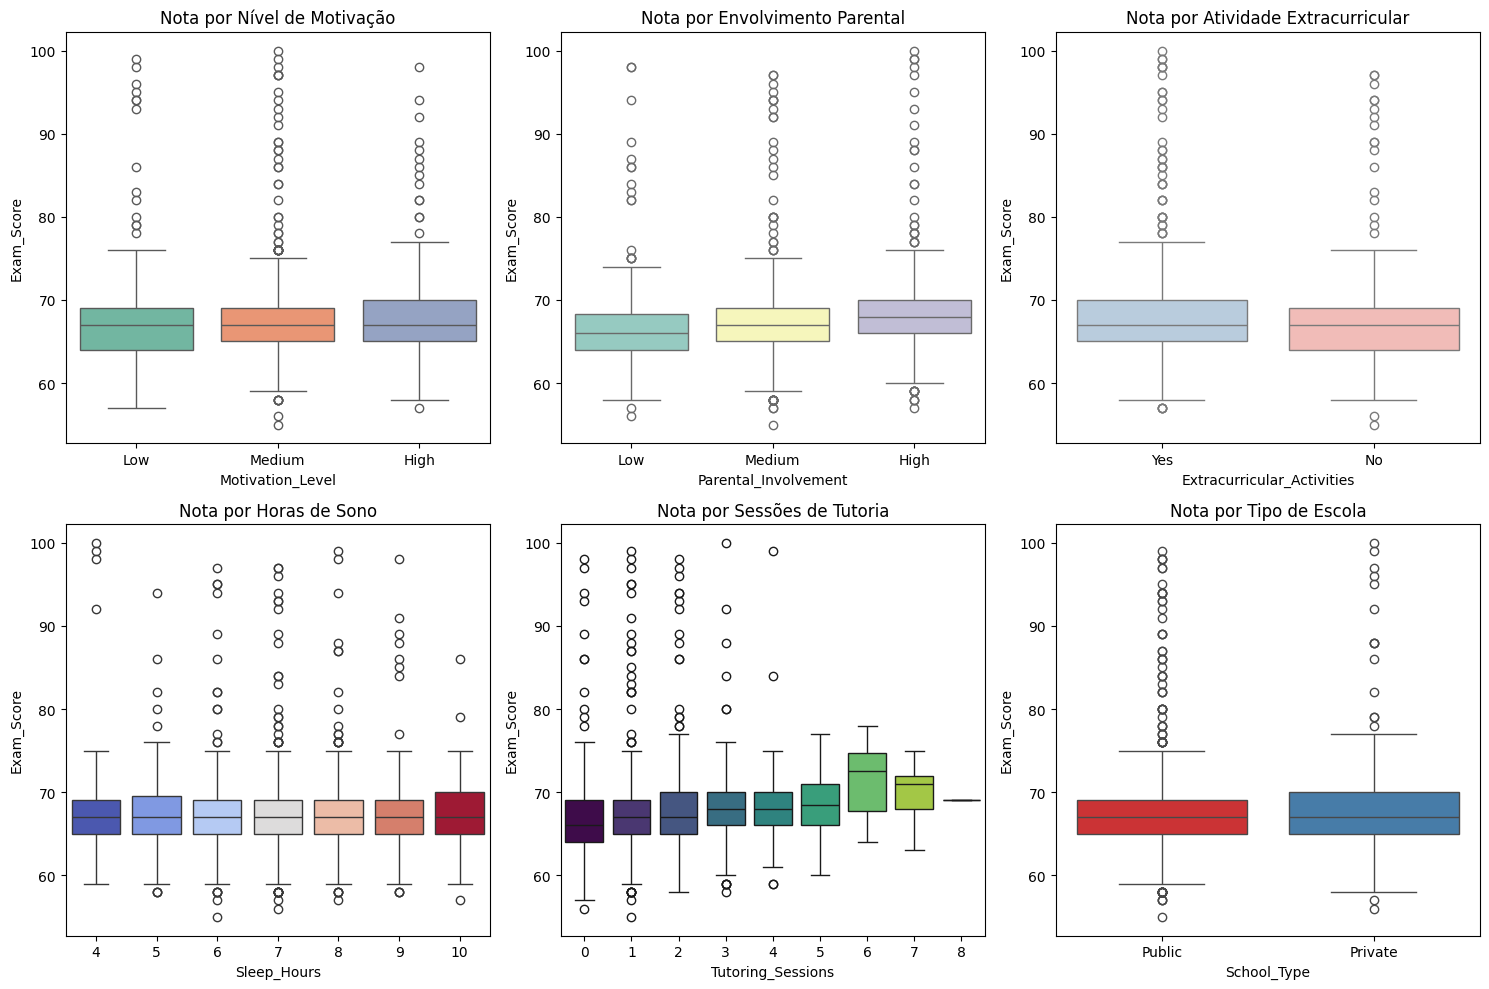

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

sns.boxplot(ax=axes[0], x='Motivation_Level', y='Exam_Score', data=df,
            order=['Low', 'Medium', 'High'], palette='Set2', hue='Motivation_Level', legend=False)
axes[0].set_title('Nota por Nível de Motivação')

sns.boxplot(ax=axes[1], x='Parental_Involvement', y='Exam_Score', data=df,
            order=['Low', 'Medium', 'High'], palette='Set3', hue='Parental_Involvement', legend=False)
axes[1].set_title('Nota por Envolvimento Parental')

sns.boxplot(ax=axes[2], x='Extracurricular_Activities', y='Exam_Score', data=df,
            order=['Yes', 'No'], palette='Pastel1', hue='Extracurricular_Activities', legend=False)
axes[2].set_title('Nota por Atividade Extracurricular')

sleep_order = sorted(df['Sleep_Hours'].unique())
sns.boxplot(ax=axes[3], x='Sleep_Hours', y='Exam_Score', data=df,
            order=sleep_order, palette='coolwarm', hue='Sleep_Hours', legend=False)
axes[3].set_title('Nota por Horas de Sono')

tutor_order = sorted(df['Tutoring_Sessions'].unique())
sns.boxplot(ax=axes[4], x='Tutoring_Sessions', y='Exam_Score', data=df,
            order=tutor_order, palette='viridis', hue='Tutoring_Sessions', legend=False)
axes[4].set_title('Nota por Sessões de Tutoria')

sns.boxplot(ax=axes[5], x='School_Type', y='Exam_Score', data=df,
            palette='Set1', hue='School_Type', legend=False)
axes[5].set_title('Nota por Tipo de Escola')

plt.tight_layout()
plt.show()

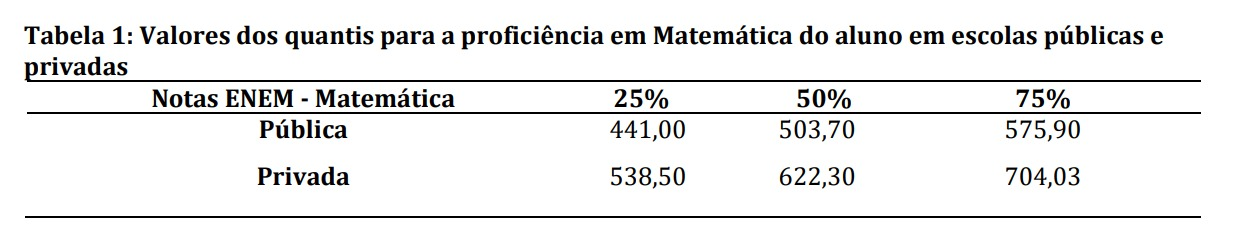

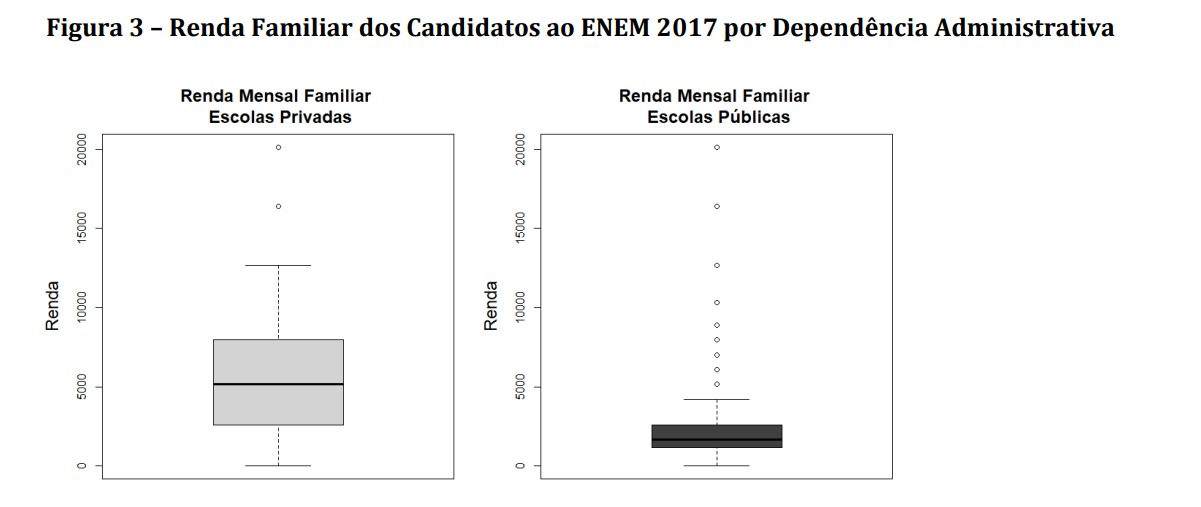

MORAES, Caroline Ponce de; PERES, Rodrigo Tosta. Reflexões sobre diferenças de desempenho no ENEM: Uma análise socioeconômica e escolar do Sudeste do Brasil. J. Pol. Educ-s,  Curitiba ,  v. 16,  e85377,    2022 .   Disponível em <http://educa.fcc.org.br/scielo.php?script=sci_arttext&pid=S1981-19692022000100117&lng=pt&nrm=iso>. acessos em  06  maio  2026.  Epub 30-Maio-2023.  https://doi.org/10.5380/jpe.v16i0.85377.

Em 16 países da OCDE e em 10 países e economias parceiras, o típico
estudante de escola privada alcança desempenho melhor do que o típico
estudante de escola pública. Essa “vantagem” da escola privada revela-se nos resultados de
Leitura do PISA, que são 30 pontos mais altos – o equivalente a três quartos de um ano de
escolaridade normal – entre os alunos das escolas privadas em comparação aos das escolas
públicas, nos países da OCDE

*PISA EM FOCO 7/2011 (Agosto) – © OCDE 2011*

### Cálculo de Eficiência de Estudo

Eficiência: Min 1.61 | Máx 92.00


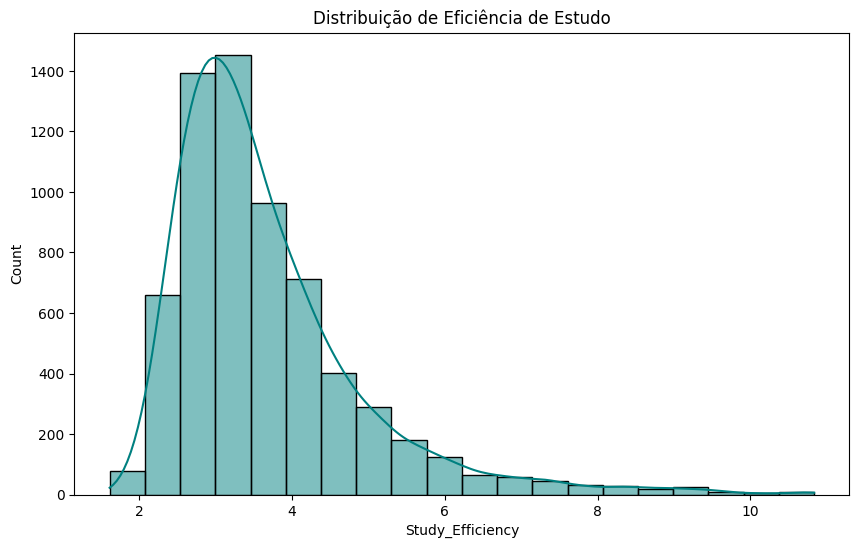

In [ ]:
df_analise = df.copy()

df_analise['Study_Efficiency'] = np.where(
    df_analise['Hours_Studied'] > 0,
    df_analise['Exam_Score'] / df_analise['Hours_Studied'],
    np.nan
)

print(f"Eficiência: Min {df_analise['Study_Efficiency'].min():.2f} | Máx {df_analise['Study_Efficiency'].max():.2f}")

limite_superior = df_analise['Study_Efficiency'].quantile(0.99)
df_plot = df_analise[(df_analise['Study_Efficiency'] <= limite_superior) & (df_analise['Hours_Studied'] >= 1)].copy()

plt.figure(figsize=(10, 6))
sns.histplot(df_plot['Study_Efficiency'], bins=20, kde=True, color='teal')
plt.title('Distribuição de Eficiência de Estudo')
plt.show()

### Evolução da Nota vs. Horas de Estudo

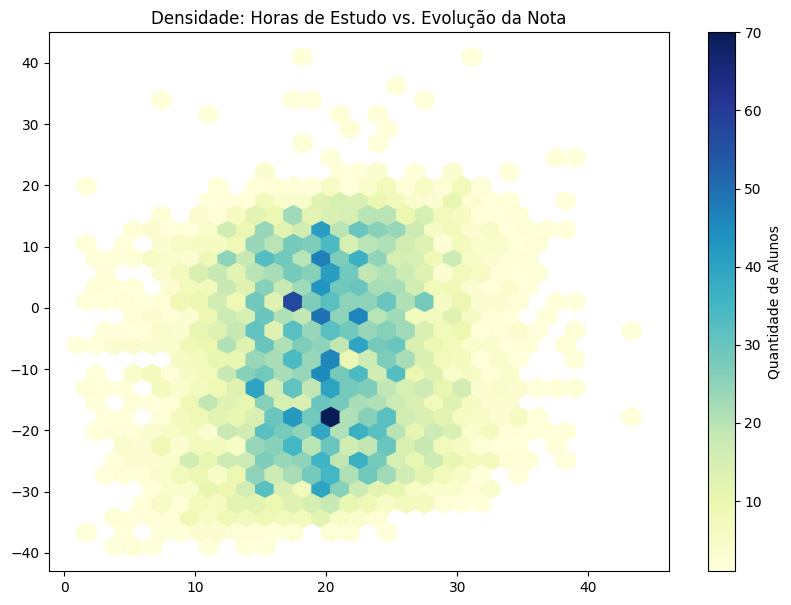

In [ ]:
df_analise['Score_Improvement'] = df_analise['Exam_Score'] - df_analise['Previous_Scores']

plt.figure(figsize=(10, 7))
plt.hexbin(df_analise['Hours_Studied'], df_analise['Score_Improvement'],
           gridsize=30, cmap='YlGnBu', mincnt=1)
plt.colorbar(label='Quantidade de Alunos')
plt.title('Densidade: Horas de Estudo vs. Evolução da Nota')
plt.show()

### Evolução da Nota por Renda Familiar

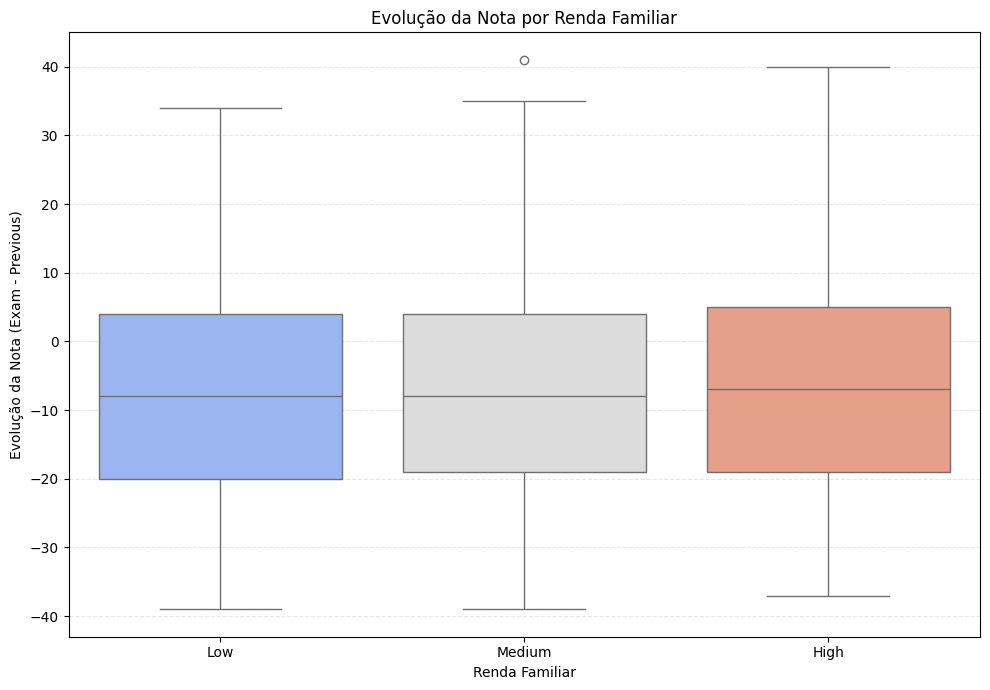

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(10, 7))

sns.boxplot(ax=axes, x='Family_Income', y='Score_Improvement', data=df_analise, palette='coolwarm', hue='Family_Income', legend=False)
axes.set_title('Evolução da Nota por Renda Familiar')
axes.set_xlabel('Renda Familiar')
axes.set_ylabel('Evolução da Nota (Exam - Previous)')
axes.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Evolução da Nota e Impacto da Tutoria

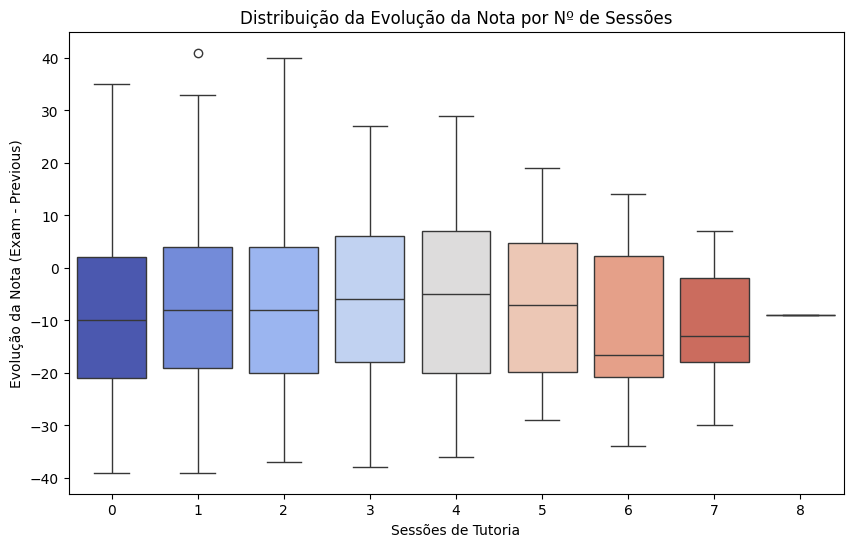

Média de Evolução da Nota por quantidade de Sessões:
Tutoring_Sessions
0    -9.178453
1    -7.836622
2    -7.723469
3    -6.345694
4    -6.006645
5    -6.656863
6   -10.944444
7   -10.857143
8    -9.000000
Name: Score_Improvement, dtype: float64


In [ ]:
df_analise['Score_Improvement'] = df_analise['Exam_Score'] - df_analise['Previous_Scores']

df_analise['Improvement_Per_Session'] = np.where(
    df_analise['Tutoring_Sessions'] > 0,
    df_analise['Score_Improvement'] / df_analise['Tutoring_Sessions'],
    0
)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Tutoring_Sessions', y='Score_Improvement', data=df_analise, palette='coolwarm', hue='Tutoring_Sessions', legend=False)
plt.title('Distribuição da Evolução da Nota por Nº de Sessões')
plt.xlabel('Sessões de Tutoria')
plt.ylabel('Evolução da Nota (Exam - Previous)')
plt.show()

print("Média de Evolução da Nota por quantidade de Sessões:")
print(df_analise.groupby('Tutoring_Sessions')['Score_Improvement'].mean())

### Evolução da Nota por Atributos Categóricos

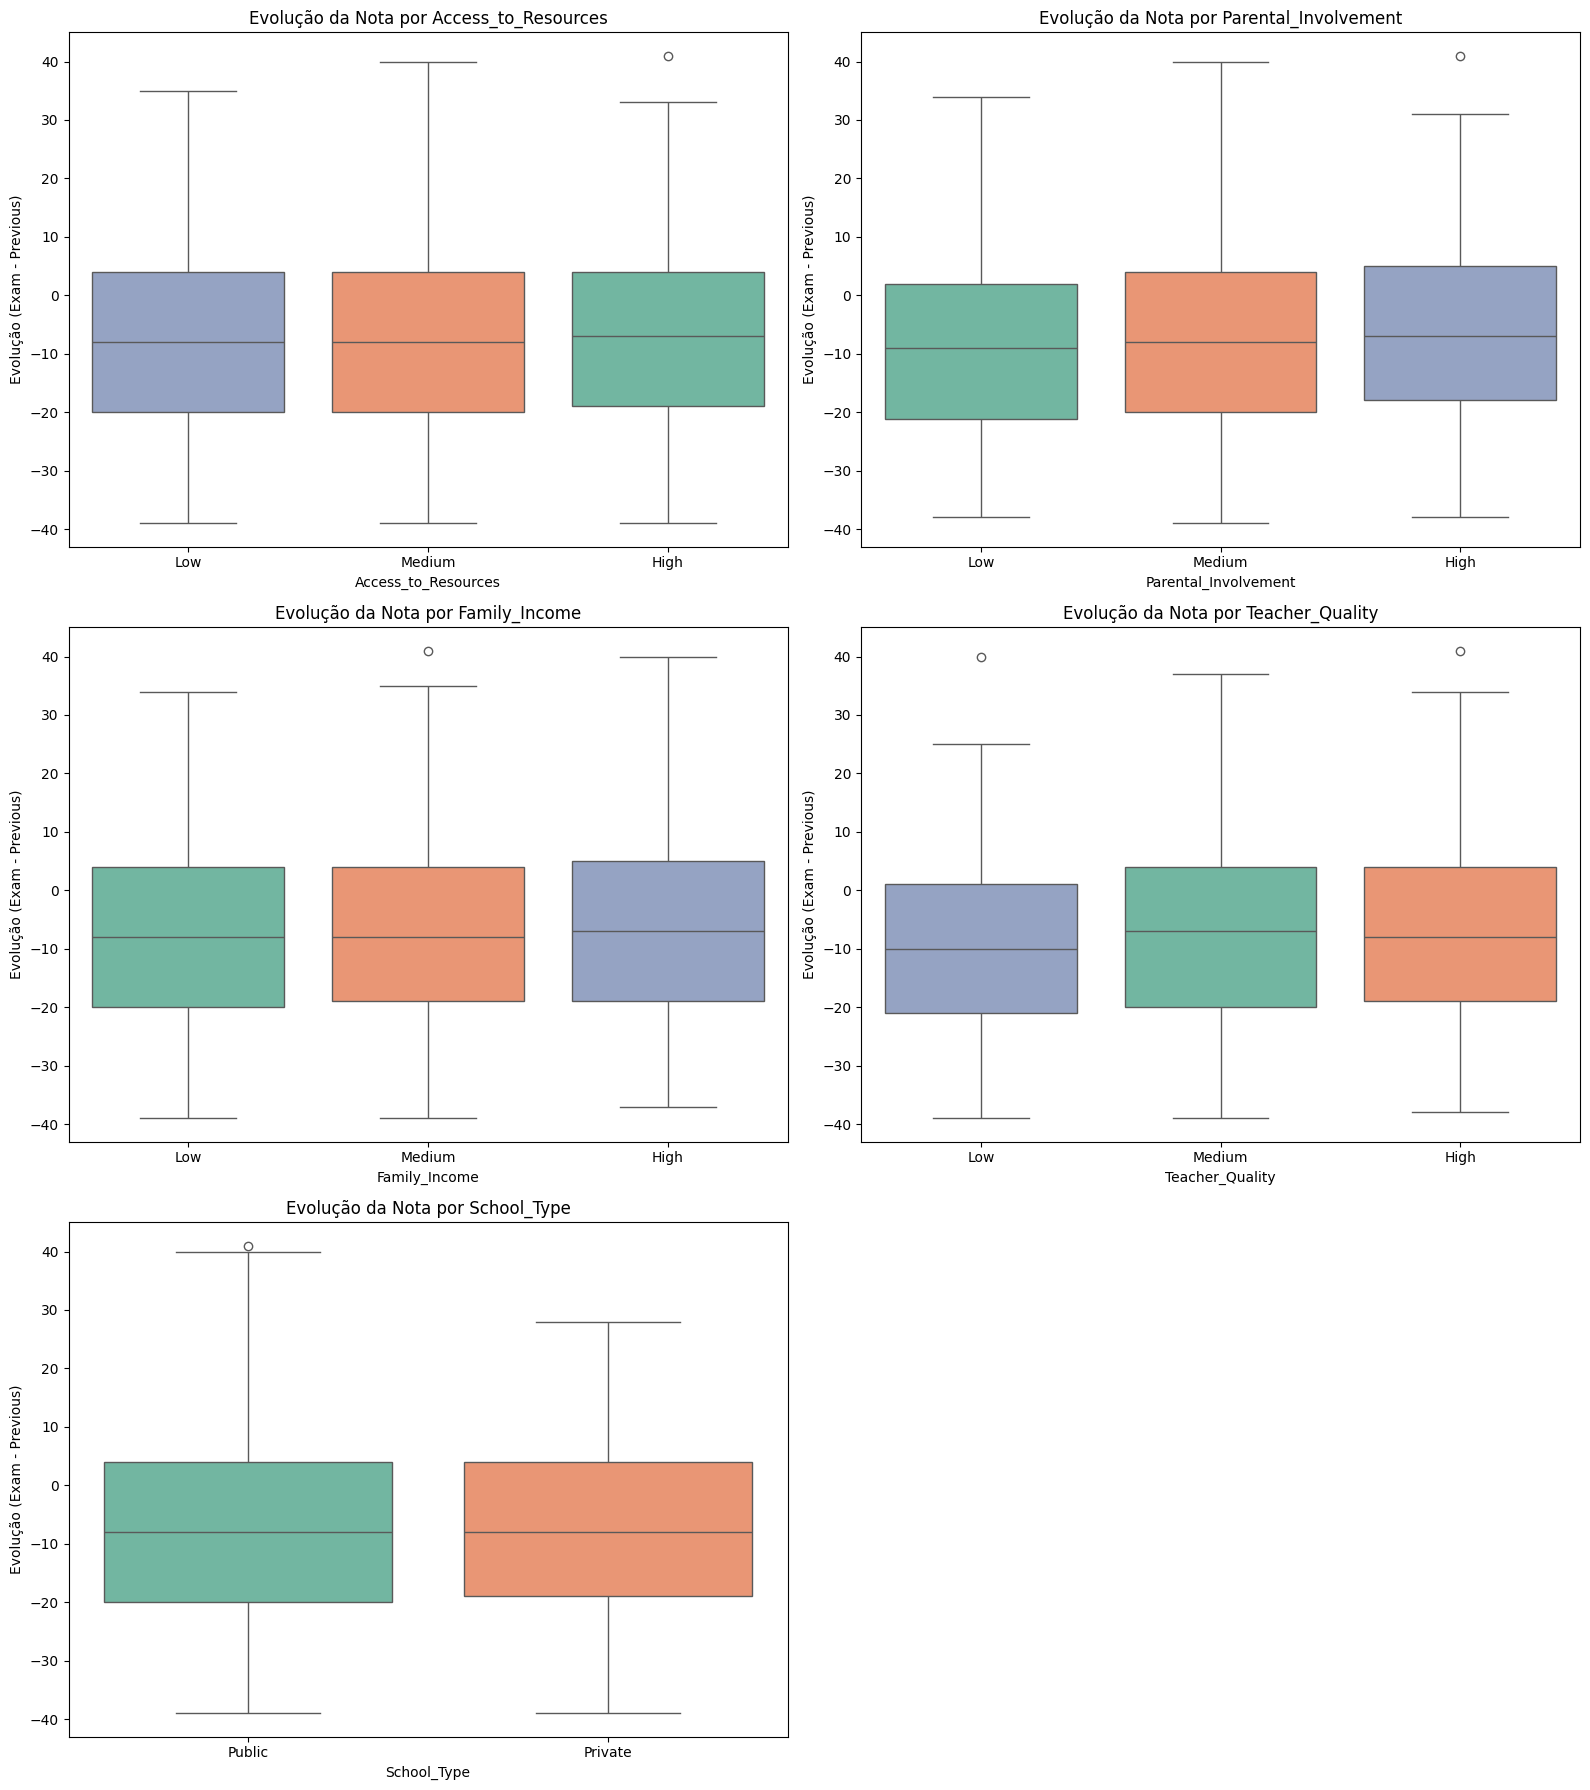

In [ ]:
categorical_vars = [
    'Access_to_Resources', 'Parental_Involvement',
    'Family_Income', 'Teacher_Quality', 'School_Type'
]

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

ordem = ['Low', 'Medium', 'High']

for i, var in enumerate(categorical_vars):
    current_order = ordem if var in ['Access_to_Resources', 'Parental_Involvement', 'Family_Income', 'Teacher_Quality'] else None

    sns.boxplot(
        ax=axes[i],
        x=var,
        y='Score_Improvement',
        data=df_analise,
        palette='Set2',
        order=current_order,
        hue=var,
        legend=False
    )
    axes[i].set_title(f'Evolução da Nota por {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Evolução (Exam - Previous)')

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

### Análise por Escolaridade dos Pais

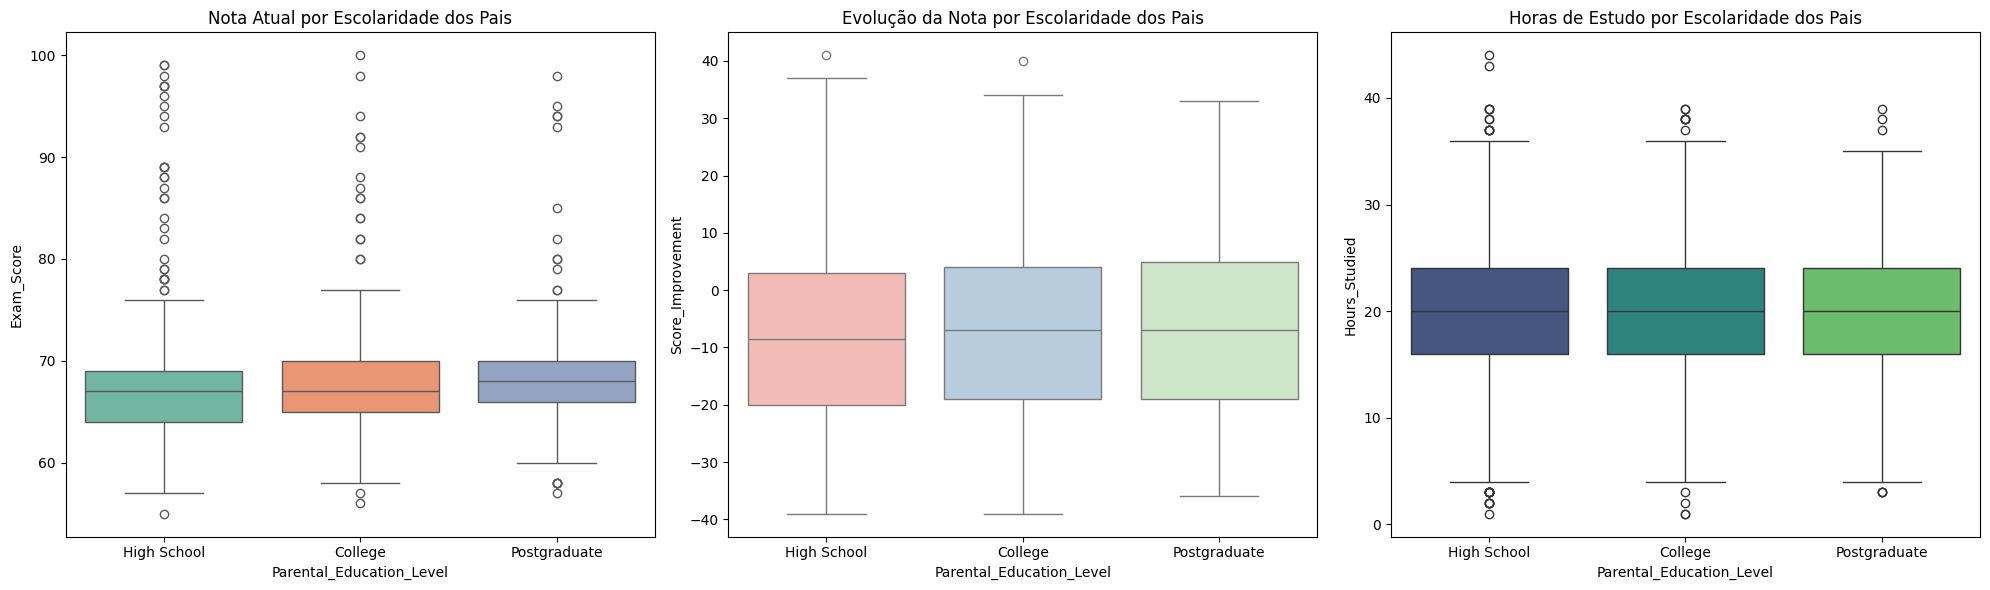

,Exam_Score,Score_Improvement,Hours_Studied
Parental_Education_Level,,,
High School,66.882992,-8.477964,20.037554
College,67.315737,-7.330317,19.847662
Postgraduate,67.970881,-7.109579,19.963985


In [ ]:
education_order = ['High School', 'College', 'Postgraduate']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(ax=axes[0], x='Parental_Education_Level', y='Exam_Score', data=df, order=education_order, palette='Set2', hue='Parental_Education_Level', legend=False)
axes[0].set_title('Nota Atual por Escolaridade dos Pais')

sns.boxplot(ax=axes[1], x='Parental_Education_Level', y='Score_Improvement', data=df_analise, order=education_order, palette='Pastel1', hue='Parental_Education_Level', legend=False)
axes[1].set_title('Evolução da Nota por Escolaridade dos Pais')

sns.boxplot(ax=axes[2], x='Parental_Education_Level', y='Hours_Studied', data=df, order=education_order, palette='viridis', hue='Parental_Education_Level', legend=False)
axes[2].set_title('Horas de Estudo por Escolaridade dos Pais')

plt.tight_layout()
plt.show()

resumo_pais = df_analise.groupby('Parental_Education_Level')[['Exam_Score', 'Score_Improvement', 'Hours_Studied']].mean().reindex(education_order)
display(resumo_pais)

### Estatísticas de Notas Anteriores e Atuais

## Análise de Evolução por Faixas de Nota Anterior
Para entender o peso de `Previous_Scores` na evolução, vamos dividir os alunos em tercis (Baixo, Médio e Alto) e observar o comportamento do `Score_Improvement`.

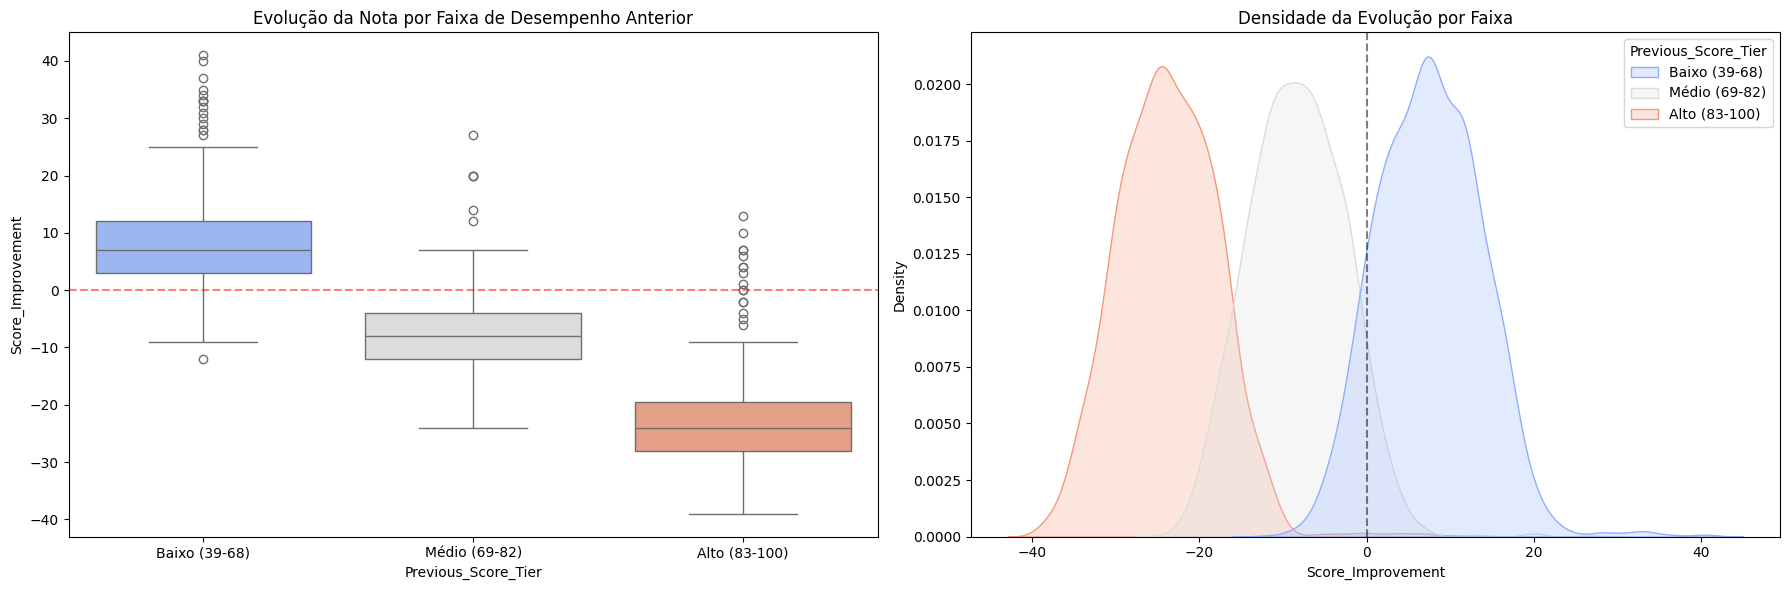

,count,mean,std,min,25%,50%,75%,max
Previous_Score_Tier,,,,,,,,
Baixo (39-68),2305.0,7.613015,6.261407,-12.0,3.0,7.0,12.0,41.0
Médio (69-82),2110.0,-8.279621,5.752317,-24.0,-12.0,-8.0,-4.0,27.0
Alto (83-100),2191.0,-23.665450,6.053708,-39.0,-28.0,-24.0,-19.5,13.0


In [ ]:
df_analise['Previous_Score_Tier'] = pd.qcut(
    df_analise['Previous_Scores'],
    q=3,
    labels=['Baixo (39-68)', 'Médio (69-82)', 'Alto (83-100)']
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(
    ax=axes[0],
    x='Previous_Score_Tier',
    y='Score_Improvement',
    data=df_analise,
    palette='coolwarm',
    hue='Previous_Score_Tier',
    legend=False
)
axes[0].set_title('Evolução da Nota por Faixa de Desempenho Anterior')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)

sns.kdeplot(
    ax=axes[1],
    data=df_analise,
    x='Score_Improvement',
    hue='Previous_Score_Tier',
    fill=True,
    palette='coolwarm'
)
axes[1].set_title('Densidade da Evolução por Faixa')
axes[1].axvline(0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

display(df_analise.groupby('Previous_Score_Tier', observed=False)['Score_Improvement'].describe())

In [ ]:
print("Estatísticas Descritivas para Notas Anteriores e Notas Atuais:")
display(df_analise[['Previous_Scores', 'Exam_Score']].describe())

Estatísticas Descritivas para Notas Anteriores e Notas Atuais:


,Previous_Scores,Exam_Score
count,6606.000000,6606.000000
mean,75.067817,67.230548
std,14.399184,3.868502
min,50.000000,55.000000
25%,63.000000,65.000000
50%,75.000000,67.000000
75%,88.000000,69.000000
max,100.000000,100.000000


### Análise de Nota Média, Sono e Atividade Física

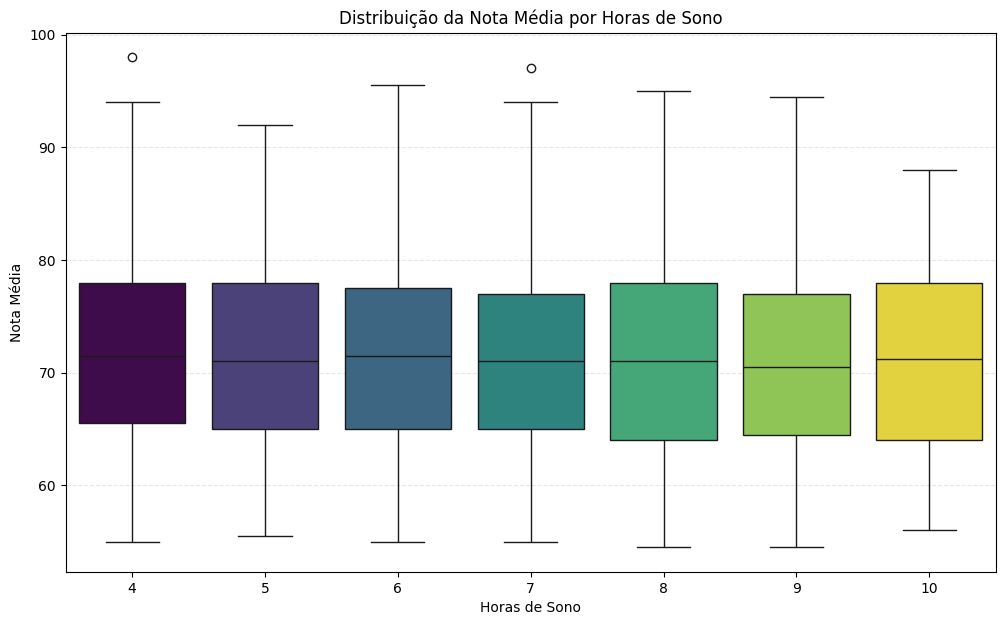

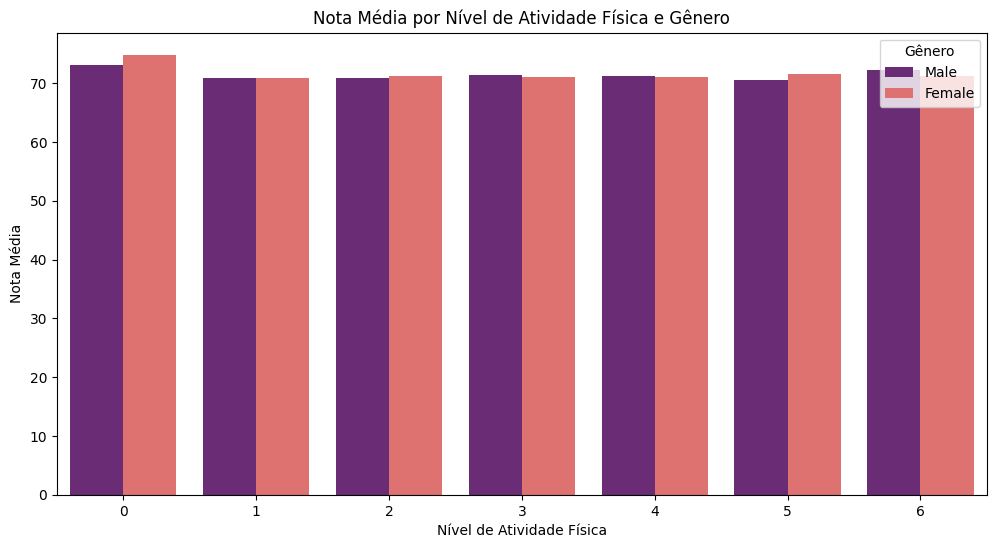

In [ ]:
df_encoded['Average_Score'] = (df_encoded['Previous_Scores'] + df_encoded['Exam_Score']) / 2
df_analise['Average_Score'] = (df_analise['Previous_Scores'] + df_analise['Exam_Score']) / 2

plt.figure(figsize=(12, 7))
sns.boxplot(
    x='Sleep_Hours',
    y='Average_Score',
    data=df_encoded,
    palette='viridis',
    hue='Sleep_Hours',
    legend=False
)
plt.title('Distribuição da Nota Média por Horas de Sono')
plt.xlabel('Horas de Sono')
plt.ylabel('Nota Média')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_analise,
    x="Physical_Activity",
    y="Average_Score",
    hue="Gender",
    palette="magma",
    errorbar=None
)
plt.title('Nota Média por Nível de Atividade Física e Gênero')
plt.xlabel('Nível de Atividade Física')
plt.ylabel('Nota Média')
plt.legend(title='Gênero')
plt.show()

In [ ]:
q_high = df_analise['Study_Efficiency'].quantile(0.98)
df_limpo = df_analise[df_analise['Study_Efficiency'] <= q_high].copy()

resumo_ld = df_limpo.groupby('Learning_Disabilities', observed=False).agg({
    'Average_Score': 'median',
    'Attendance': 'median',
    'Tutoring_Sessions': 'median',
    'Study_Efficiency': 'median'
}).round(2)

display(resumo_ld)

,Average_Score,Attendance,Tutoring_Sessions,Study_Efficiency
Learning_Disabilities,,,,
No,71.0,80.0,1.0,3.33
Yes,71.0,79.0,1.0,3.34


### Painel de Fatores Chave vs. Nota do Exame

## Análise Detalhada: Fatores Chave vs. Nota do Exame

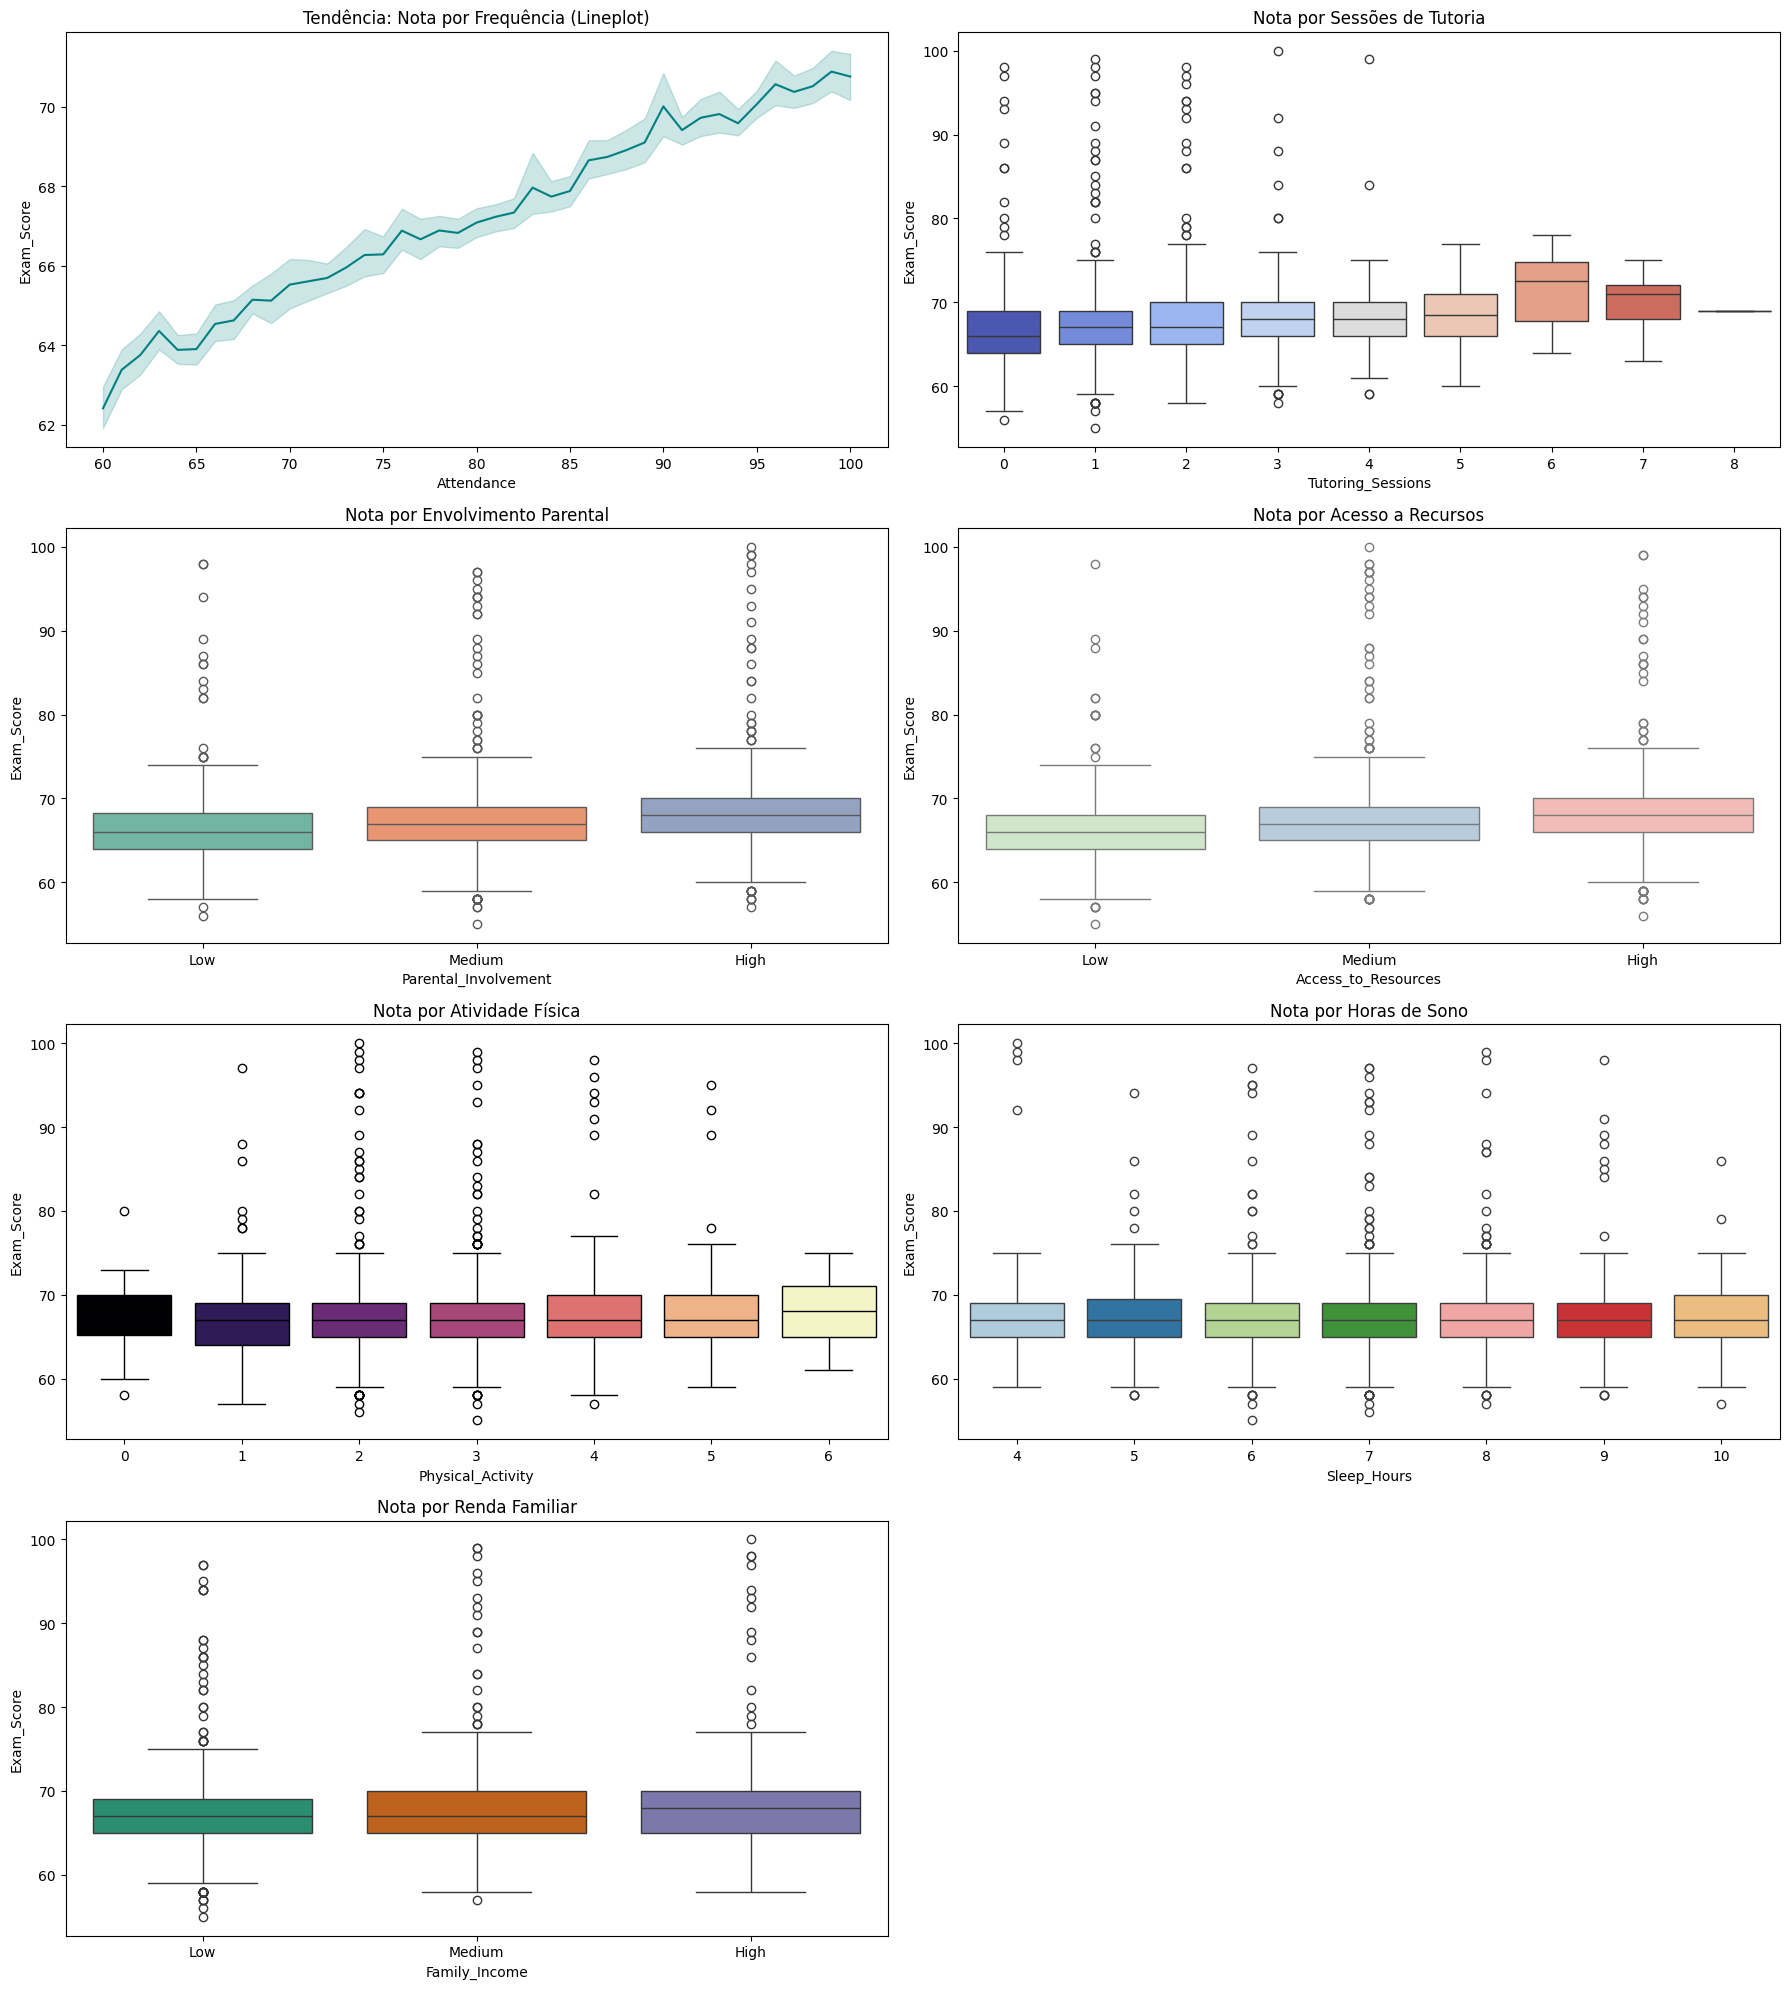

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten()
ordem_low_medium_high = ['Low', 'Medium', 'High']

sns.lineplot(ax=axes[0], x='Attendance', y='Exam_Score', data=df, color='teal')
axes[0].set_title('Tendência: Nota por Frequência (Lineplot)')

sns.boxplot(ax=axes[1], x='Tutoring_Sessions', y='Exam_Score', data=df, palette='coolwarm', hue='Tutoring_Sessions', legend=False)
axes[1].set_title('Nota por Sessões de Tutoria')

sns.boxplot(ax=axes[2], x='Parental_Involvement', y='Exam_Score', data=df, order=ordem_low_medium_high, palette='Set2', hue='Parental_Involvement', legend=False)
axes[2].set_title('Nota por Envolvimento Parental')

sns.boxplot(ax=axes[3], x='Access_to_Resources', y='Exam_Score', data=df, order=ordem_low_medium_high, palette='Pastel1', hue='Access_to_Resources', legend=False)
axes[3].set_title('Nota por Acesso a Recursos')

sns.boxplot(ax=axes[4], x='Physical_Activity', y='Exam_Score', data=df, palette='magma', hue='Physical_Activity', legend=False)
axes[4].set_title('Nota por Atividade Física')

sns.boxplot(ax=axes[5], x='Sleep_Hours', y='Exam_Score', data=df, palette='Paired', hue='Sleep_Hours', legend=False)
axes[5].set_title('Nota por Horas de Sono')

sns.boxplot(ax=axes[6], x='Family_Income', y='Exam_Score', data=df, order=ordem_low_medium_high, palette='Dark2', hue='Family_Income', legend=False)
axes[6].set_title('Nota por Renda Familiar')

fig.delaxes(axes[7])
plt.tight_layout()
plt.show()

### Regressão: Horas de Estudo vs. Nota

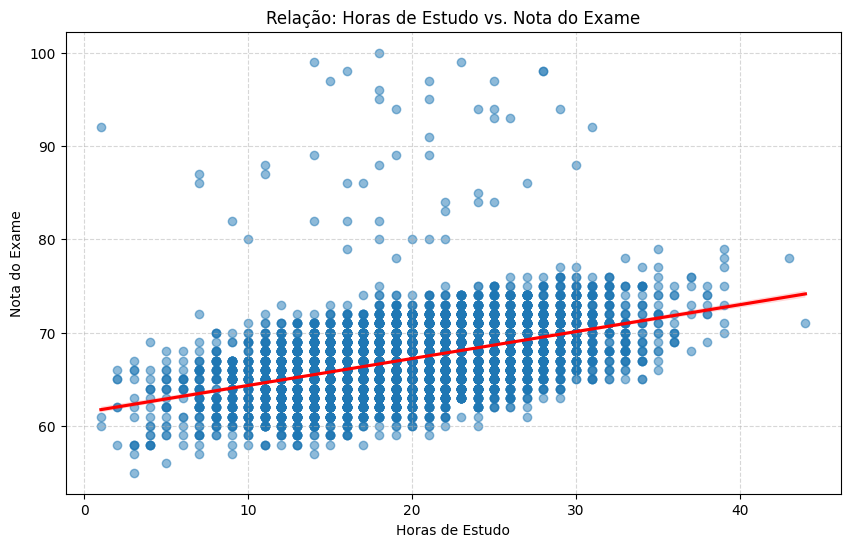

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Hours_Studied', y='Exam_Score', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relação: Horas de Estudo vs. Nota do Exame')
plt.xlabel('Horas de Estudo')
plt.ylabel('Nota do Exame')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 4. Conclusões e Insights Finais

### Impacto dos Fatores Socioeconômicos
Observamos uma **baixa variabilidade** nas notas quando analisamos isoladamente o tipo de escola (Pública vs. Privada), o acesso a recursos e a renda familiar. Embora a literatura aponte disparidades, nesta base de dados específica, esses fatores não foram os diferenciais determinantes para o sucesso imediato no exame.

### Principais Preditores de Desempenho
A análise de importância de atributos (Random Forest) e as correções visuais confirmam que o desempenho é impulsionado por fatores de continuidade e engajamento:
1. **Desempenho Prévio (`Previous_Scores`):** O maior preditor da nota atual, indicando que o conhecimento acumulado é a base mais forte.
2. **Frequência Escolar (`Attendance`):** Demonstrou uma correlação direta com as notas, sendo o fator comportamental mais relevante.
3. **Hábitos de Estudo (`Hours_Studied`):** O tempo dedicado reflete positivamente no resultado final.

### Eficiência e Suporte
- A **Tutoria** e o **Envolvimento Parental** mostram benefícios marginais, mas consistentes, ajudando a elevar a média de alunos que partem de uma base menor.
- A **Eficiência de Estudo** variou significativamente, sugerindo que *como* o aluno estuda pode ser tão importante quanto *quanto* ele estuda.

**Recomendação:** Focar em programas de retenção e presença escolar, além de reforço contínuo para alunos com histórico de notas baixas, independentemente do contexto socioeconômico.